In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score,
    f1_score, roc_curve, auc
)

# **Deforestation: a new categorical problem**
In this project, we will transition from simple linear regression to logistical regressions. Here we will use a pre-processed and analyzed csv (one that you can see in the deforestation data insights project in my githu repo). Using then the deforestation + country data csv, constructed and cleaned in the past we will do now a categorical approach to it.

**Refreshment & Context on Database**

In order to give context on the dataset is a mix of environmental, social, economic and other relevant data of specific countries. For this project, the dataset combines environmental, social, and economic indicators for a set of countries, previously cleaned and analyzed in the linear regression phase of this course.arget varaobale selction, there was a data cleaning, espeically considering the possibility of nulls, data that is redundant, with mistakes, etc. Thus the datasets contains 35 variables including :
- `Deforestation`: hectares of forest lost per year
- `Urban_population`: people living in urban areas
- `Physicians per thousand`: doctors per 1,000 people (proxy for institutional quality)
- `Density` (P/Km²): population density
- `Total tax rate`: tax burden on businesses (% of commercial profits)
- `Labor force participation` (%): share of working-age population employed
- `Gasoline Price`: average retail price USD/liter
- `Latitude / Longitude`: geographic position of country centroid
- `CPI Change` (%):	annual inflation rate
- `Infant mortality`: deaths per 1,000 live births
- `Agricultural Land` (%): Share of land area that is arable, under permanent crops, or under permanent pastures.
- `Armed Forces size`: number of armed forces personnel, reflecting state investment in military infrastructure.
- `Co2-Emissions`: Carbon dioxide emissions.
- `CPI` (Consumer Price Index): A measure of the average change over time in the prices paid by urban consumers for a market basket of consumer goods and services.
- `GDP`: Gross Domestic Product, serving as the core indicator of the country's overall economic size and health.
- `Gross primary education enrollment` (%): Ratio of total primary enrollment to the population of the age group that officially corresponds to primary education.
- `Gross tertiary education enrollment` (%): Ratio of total tertiary enrollment to the population of the age group that officially corresponds to university-level education.
- `Minimum wage`: lowest legally permissible compensation for workers.
- `Out of pocket health expenditure`: share of healthcare costs paid directly by households.
- `Tax revenue (%)`: transfers to the central government for public purposes, expressed as a percentage of GDP.
- `Unemployment rate`: share of the labor force that is without work but seeking.
- Land Area:

**First Steps**

In the previous project (Deforestation, where the csv was extracted from), the primary objective was to model deforestation as a continuous numerical variable using regression techniques. For this project, the focus shifts toward a **classification** approach. To achieve this, the original continuous target (annual deforestation rate) must be transformed into a discrete, binary variable representing the risk level. Thus we will create a variable `Deforestation_Risk` (0 = Low/Moderate Risk, 1 = High Risk). However, one of the first things to study and anlyze will be how to establish the accurate threshold for this new categorical variable, two distinct approaches will be evaluated:

1. The Median: Utilizing the median of the dataset ensures a perfectly balanced distribution between the two classes (50% Low Risk, 50% High Risk). While machine learning models (particularly Logistic Regression) perform optimally with balanced data, an arbitrary statistical cutoff may lack real-world significance.

2. Literature Review: This involves defining the threshold based on established ecological alarms from environmental organizations, such as the UN or FAO. While this method aligns the model with real-world ecological contexts, it is highly likely to introduce class imbalance, requiring specialized techniques during the modelling.


In [3]:
# csv path
path = '/content/drive/My Drive/Colab Notebooks/AI/simplified_df.csv'

# convert to a dataframe
df = pd.read_csv(path)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df.head()

,Unnamed: 0,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Co2-Emissions,CPI,CPI Change (%),Forested Area (%),Gasoline Price,GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Infant mortality,Minimum wage,Out of pocket health expenditure,Physicians per thousand,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude,Deforestation
0,0,2.944439,17.4,14.683343,12.666660,150006.0,151.36,2.000,0.8,0.28,25.858995,109.9,51.4,3.049273,0.667829,28.1,1.72,41.2,37.2,66.100,11.70,17.265819,28.033886,1.659626,9.067739
1,1,3.295837,47.5,14.036011,11.669938,34693.0,261.73,17.100,46.3,0.97,25.273298,113.5,9.3,3.962716,0.536493,33.4,0.21,77.5,9.2,49.100,6.89,16.862935,-11.202692,17.873887,13.143030
2,2,2.890372,54.3,14.838106,11.561725,201348.0,232.75,53.375,9.8,1.10,26.831765,109.7,90.0,2.282382,1.470176,17.6,3.96,61.3,10.1,104.955,9.79,17.537331,-38.416097,-63.616672,12.182297
3,3,4.700480,32.4,11.337047,9.952325,61448.0,118.06,1.500,46.9,1.20,26.824290,103.1,85.1,1.360977,2.311148,17.9,5.17,60.7,25.4,51.400,4.67,15.463095,47.516231,14.550072,8.543056
4,4,7.714231,11.1,6.641182,9.852247,31694.0,117.59,2.100,0.8,0.43,24.375846,99.4,50.5,1.960095,1.213725,25.1,0.93,73.4,4.2,13.800,0.71,14.198805,26.066700,50.557700,0.000000


To transition our target variable into a categorical classification (High Risk vs. Low Risk), we first researched real-world ecological baselines. According to recent studies [1], a country is considered at "critical risk" when its annual deforestation rate exceeds 0.501% of its land. The research also notes that applying this real-world threshold will naturally result in class imbalance. This is because global deforestation is highly unequal: the millions of hectares lost annually are driven by a small concentration of countries (due  economic drivers, lax legislation, and massive existing forest areas) compared to desert or highly developed nations with minimal forest loss. So based on this, we need to calculate the actual deforestation percentages for our dataset and compare them against statistical thresholds. To achieve this, we will follow these methodological steps:
1. As seen in our earlier `.head()` exploration, the Deforestation variable and the Land Area (km2) are log-transformed. We must first apply the exponential function to revert these values back to their absolute "normal" scale.
2. We have to transform the km2 of forested area and the hectares of deforestation to the same unit to get the appropriate variable. Thus we will then transform the KM2 to He multiplying the value times 100.
3. We will generate our new target variable by dividing the true hectares of deforestation by the total forested land area in hectares for each country (which is gotten with the help of the `Forested Area (%)` multiplied by the total `Land Area (Km2)`), multiplying by 100 to get the percentage.
4. Finally, we will run the `.describe()` function on this new percentage variable. By comparing our dataset's empirical median and 75th percentile against the 0.501% literature threshold, we will make an informed, data-driven decision on the final cutoff for our Logistic Regression model.

In [4]:
# Convert Forested Area to a true decimal (e.g., 48.0 becomes 0.48)
df['Forested_Area_Decimal'] = df['Forested Area (%)'].astype(float) / 100

# Revert the log transformation for Deforestation and Land Area!
df['Deforestation_Hectares'] = np.exp(df['Deforestation'])
df['Land_Area_Real_Km2'] = np.exp(df['Land Area(Km2)'])

# Transform real Km2 to Hectares (1 Km2 = 100 Hectares)
df['Land_Area_Hectares'] = df['Land_Area_Real_Km2'] * 100

# Calculate the actual Forest Area in hectares
df['Total_Forest_Hectares'] = df['Land_Area_Hectares'] * df['Forested_Area_Decimal']

# Create the new variable of % forested area deforested
df['Deforestation_Rate_%'] = (df['Deforestation_Hectares'] / df['Total_Forest_Hectares']) * 100

display(df[['Deforestation_Hectares', 'Total_Forest_Hectares', 'Deforestation_Rate_%']].head())

,Deforestation_Hectares,Total_Forest_Hectares,Deforestation_Rate_%
0,8671.0,1905393.6,0.455077
1,510441.0,57722256.3,0.884305
2,195301.0,27247929.8,0.716755
3,5131.0,3933596.8,0.130440
4,1.0,612.8,0.163185


In [5]:
df['Deforestation_Rate_%'].describe().round(5)

,Deforestation_Rate_%
count,106.00000
mean,inf
std,NaN
min,0.00000
25%,0.01994
50%,0.13507
75%,0.78236
max,inf


Upon calculating the new Deforestation_Rate_% column, the initial statistical summary returned a mean of inf (infinity) and a standard deviation of NaN. This anomaly indicates a division-by-zero error, which naturally occurs because certain countries (e.g., desertic nations) can have a 0% forest cover.

Since it is ecologically impossible to measure the deforestation rate of a country with no forests, these mathematical edge cases must be handled before continuing. In the following cell, we will replace these infinite values with nulls (NaN), remove them from our analysis, and generate a clean, rounded statistical summary to help us define our final threshold.

In [6]:
# Drop the rows representing countries with no forest to deforest
df = df[df['Forested Area (%)'] > 0.000]

# Output the cleaned and rounded statistical summary
df['Deforestation_Rate_%'].describe().round(5)

,Deforestation_Rate_%
count,103.00000
mean,0.45276
std,0.64163
min,0.00000
25%,0.01814
50%,0.13044
75%,0.70634
max,2.62770


To prevent **data leakage**, it's crucial to remove variables that are either direct components of the target variable (`Deforestation_Rate_%`) or the ones highly correlated and could provide the model with extra information about the target. We will thus drop:

*   `Land Area(Km2)`
*   `Deforestation`
*   `Deforestation_Hectares`
*   `Land_Area_Real_Km2`
*   `Land_Area_Hectares`
*   `Forested Area %`
*   `Forested_Area_Decimal`
*   `Total_Forest_Hectares`

Dropping these columns ensures that our model learns patterns from independent features rather than directly from components of the target, leading to a more robust and generalizable model.

In [7]:
columns_to_drop = [
    'Land Area(Km2)',
    'Deforestation',
    'Deforestation_Hectares',
    'Land_Area_Real_Km2',
    'Land_Area_Hectares',
    'Forested Area (%)',
    'Forested_Area_Decimal',
    'Total_Forest_Hectares'
]

df = df.drop(columns=columns_to_drop)

# Display the remaining columns to verify
print(df.columns.tolist())

['Unnamed: 0', 'Density\n(P/Km2)', 'Agricultural Land( %)', 'Armed Forces size', 'Co2-Emissions', 'CPI', 'CPI Change (%)', 'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)', 'Gross tertiary education enrollment (%)', 'Infant mortality', 'Minimum wage', 'Out of pocket health expenditure', 'Physicians per thousand', 'Population: Labor force participation (%)', 'Tax revenue (%)', 'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude', 'Deforestation_Rate_%']


Following the removal of 3 rows with 0% forested area (e.g., desertic nations where deforestation cannot be measured), our dataset was refined to 103 countries. The `.describe()` function reveals critical insights into the distribution of our new `Deforestation_Rate_%` variable.

**Observations:**
* Right-Skewed Distribution: The data is heavily right-skewed. The 50th percentile is very low at 0.13%, while the mean is pulled much higher to 0.45% by extreme outlier nations reaching up to a maximum deforestation rate of 2.62%.
* Threshold: The literature critical threshold of 0.501% sits neatly between the median and the 75th percentile (0.60%-0.70%).

While using a statistical cutoff like the median would guarantee a perfectly balanced 50/50 class distribution, doing so would classify countries with benign deforestation rates (e.g., 0.15%) as "High Risk," which is ecologically inaccurate. Alternatively, splitting at the mean (0.45%) or 75th percentile (0.70%) provides statistical convenience but lacks external scientific validation. Therefore, we will adopt the rigorous 0.501% literature threshold. Because this value falls roughly around the 70th percentile of our dataset, it will naturally yield a moderately imbalanced target variable (approximately 70% Class 0 vs. 30% Class 1). This imbalance accurately reflects the real-world reality that severe deforestation is driven by a minority of high-impact nations. To ensure our Logistic Regression model learns effectively from this minority class, we will counter the imbalance algorithmically using the `class_weight='balanced'` parameter.

Now, it is imperative to finally create the binary target using the literature threshold of 0.501 (%) and drop the deforestation_rate_% (our helper threshold variable).

In [8]:
df['Deforestation_Critical'] = (df['Deforestation_Rate_%'] > 0.501).astype(int)
df.drop(columns=['Deforestation_Rate_%'], inplace=True)

df['Deforestation_Critical'].head()

,Deforestation_Critical
0,0
1,1
2,1
3,0
4,0


## Data Splitting

While a 70/30 split is the commonality, an 80/20 ratio (doing `test_size=0.2`) was deliberately chosen for this analysis due to the smaller size of the dataset ($n=103$ of countries). In small-sample scenarios, particularly those with class imbalance, making a bigger training volume is critical to ensure the Logistic Regression algorithm gets sufficient examples of the minority class (High Risk) to converge accurately. A random split could inadvertently place all the minority class (High Risk) samples into the test set, leaving the model with no critical examples to learn from during training.

We will begin by defining the target classification variable (y) as `Deforestation_Critical` along with the features as the rest of the data (X).


In [9]:
# We drop the target AND all the temporary math columns we created so the model doesn't cheat
y = df['Deforestation_Critical']
X = df.drop(columns=['Deforestation_Critical'])

Now in order to do the best train_test split, the use of a Stratified Split (`stratify=y`) helps place equal class sizes in both sets of splitted data. In order words, stratification ensures that the exact proportion of High-Risk to Low-Risk countries is perfectly preserved across the original dataset, the training set, and the testing set. Maintaining this consistency is critical in classification problems, as it ensures the model is trained on a representative sample of reality and evaluated on a perfectly scaled miniature version of that same reality.

This will be done using the `train_test_split` function from sklearn, feeding it the parameters of `random_state = 42`, `test_size=0.2` and the `stratify=y`. After splitting the dataset, it is important to verify that the stratification successfully preserved our class distribution. We accomplish this by calculating the `value_counts()` for the target variable ($y$) across the Original, Training, and Testing sets. By using the `normalize=True`, we convert absolute row counts into relative percentages, allowing for a direct, apples-to-apples comparison across datasets of different sizes. The output below confirms that the split was consistent, the moderate-risk class (0) maintains a stable proportion of approximately 69% - 72% across all sets, while the critical-risk class (1) is perfectly preserved at approximately 28% - 31%.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# revision of class balance
print("Original Data :", y.value_counts(normalize=True).round(3))
print("\n2. Training Set :", y_train.value_counts(normalize=True).round(3))
print("\n3. Testing Set :", y_test.value_counts(normalize=True).round(3))

Original Data : Deforestation_Critical
0    0.699
1    0.301
Name: proportion, dtype: float64

2. Training Set : Deforestation_Critical
0    0.695
1    0.305
Name: proportion, dtype: float64

3. Testing Set : Deforestation_Critical
0    0.714
1    0.286
Name: proportion, dtype: float64


## Logistic Regression on Training Data & Cross Fold Validation
A fundamental requirement for Logistic Regression is **feature scaling**. `StandardScaler()` standardizes each feature's magnitude so that the logistic sigmoid function maps probabilities smoothly, complementing the log-transformations already applied to normalize the distribution shape.

To prevent **data leakage during Cross-Validation**, both the scaler and the model are wrapped into a single `Pipeline` using `make_pipeline()`. This is critical: if we were to scale all of `X_train` upfront and then run CV on the already-scaled data, each validation fold's statistics would have already been "seen" by the scaler when it computed the mean and standard deviation — making CV results artificially optimistic. With our small dataset (n≈82 training samples), this effect is especially pronounced.

By using a Pipeline, sklearn's CV engine automatically fits the scaler **only on each fold's training portion** and transforms the validation portion using those parameters, true out-of-fold evaluation. For the final model evaluation, the Pipeline is simply fitted on the full `X_train` and applied to `X_test`, maintaining the same strict separation. The model is initialized with `class_weight='balanced'` to handle the natural class imbalance.

In [11]:
# Wrap scaler + model into a Pipeline so CV fits the scaler inside each fold (no leakage)
pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
)

Before testing the model on the unseen Test set, we must estimate its expected performance using only the Training data. Relying on a single Train-Test split can be deceptive because if the split happens to be "lucky" or "unlucky," the resulting accuracy metric will not represent the model's true capability. To obtain a better estimator, we implemented Stratified **K-Fold Cross-Validation** ($k=5$) on the training data. This methodology divides the training set into 5 equal folds (maintaining class proportions in each). The Logistic Regression model is then trained on 4 folds and validated on the 1 remaining fold, iterating this process 5 times.

The key utility of Cross-Validation is that it gives us high statistical confidence in how the model will generalize to completely unseen data.

In [12]:
# Cross-Validation (5-Folds) on train Data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Because our defined threshold (0.501%) introduces a natural class imbalance (~70% Class 0 vs. 30% Class 1), relying solely on raw accuracy during cross-validation is misleading. An algorithm could achieve high baseline accuracy simply by predicting the majority class, thereby failing its primary objective of identifying high-risk countries.

To robustly evaluate the model, `cross_val_predict` is called on the **Pipeline** (`pipe`) with unscaled `X_train`. Passing the full pipeline ensures the scaler is re-fitted inside each fold — not once on the entire training set. The `method='predict_proba'` argument generates continuous out-of-fold probability scores for each country. We isolate the probability of Class 1 and apply a standard threshold of 0.5 as the baseline, focusing on the following metrics for the minority class:
- **Recall**: To ensure we are not missing critical deforesting nations (minimizing False Negatives).
- **Precision**: To evaluate the reliability of our positive predictions (minimizing False Positives).
- **F1-Score**: To confirm that `class_weight='balanced'` successfully maintained equilibrium between Precision and Recall.

In [20]:
# Generate 'out-of-fold' predictions using cross-validation
y_train_pred = cross_val_predict(pipe, X_train, y_train, cv=cv, n_jobs=-1, method='predict_proba')

# The 'predict_proba' method returns probabilities for both classes.
# We are interested in the probability of the positive class (class 1) which is the second column.
y_train_pred_class1_proba = y_train_pred[:, 1]

# Convert probabilities to binary predictions using a threshold (not the ecology one, its teh probability one)
y_train_pred_binary = (y_train_pred_class1_proba > 0.5).astype(int)

# Display the Classification Report
print("\n--- Classification Report (Cross-Validation) ---")
print(classification_report(y_train, y_train_pred_binary))


--- Classification Report (Cross-Validation) ---
              precision    recall  f1-score   support

           0       0.86      0.77      0.81        57
           1       0.58      0.72      0.64        25

    accuracy                           0.76        82
   macro avg       0.72      0.75      0.73        82
weighted avg       0.78      0.76      0.76        82



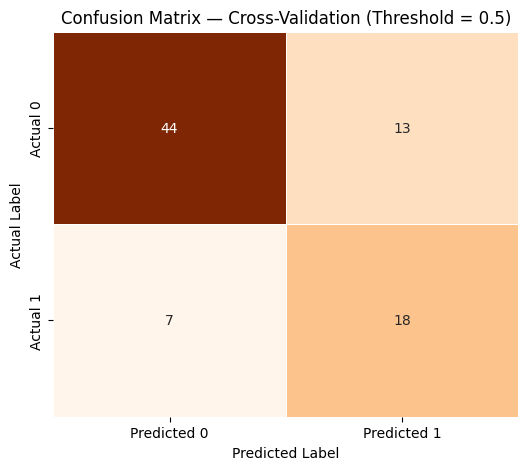

In [14]:
# Visualize the Cross-Validation Confusion Matrix as a heatmap
cm_cv = confusion_matrix(y_train, y_train_pred_binary)
cm_cv_df = pd.DataFrame(cm_cv, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm_cv_df, annot=True, fmt='d', cmap='Oranges', cbar=False, linewidths=.5)
plt.title('Confusion Matrix — Cross-Validation (Threshold = 0.5)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Based on the confusion matrix, it is observed that the model is highly effective at identifying countries that are not in a critical state (44 True Negatives), while also successfully catching 18 of the true high-risk countries (True Positives). The model only missed 7 high-risk countries (False Negatives), though it achieved this low miss rate by raising the alarm for 13 false positives.

However, achieving a recall of 72% for Class 1 on an imbalanced dataset, especially using an ecologically defined threshold rather than a purely statistical median, is a success! Catching more than 70% of the critical cases proves that the `class_weight='balanced'` parameter and the statification is working perfectly.

Overall, these cross-validation results on our training set ($n=82$) demonstrate that the Logistic Regression model successfully manages the inherent class imbalance. When the model predicts a country is at High Risk, it is correct 59% of the time (Precision). While there is a trade-off here (generating 12 false alarms), this is ecologically acceptable; over-monitoring a safe country is vastly preferable to missing a severe deforestation event. Finally, the F1-score confirms a solid, stable equilibrium between precision and recall, proving that the model has genuinely learned the data patterns and is not arbitrarily guessing the majority class.

###Different Threshold
By default, Logistic Regression uses a 0.5 (50%) probability threshold to separate the classes. However, because the dataset is imbalanced and the cost of missing a deforesting nation (False Negative) is much higher than investigating a safe one (False Positive), the boundary will be shifted to see new behaviours and test on the matrix once more.

Using the out-of-fold probabilities generated during Cross-Validation (predict_proba), the model's performance can be simulated across multiple strictness levels. Lowering the threshold (e.g., to 0.3) makes the model more sensitive, prioritizing Recall. Raising it (e.g., to 0.7) makes the model more conservative, prioritizing Precision. Analyzing this trade-off helps to optimize the threshold for specific objectives before final testing. In this case, a loop through 3 different thersholds can show the behavious and metrics for the different ranges 0.3, 0.4 and 0.7

In [15]:
threshs = [0.3, 0.4, 0.6]
for t in threshs:
  #Apply the new threshold to our existing CV probabilities
  y_pred_custom_threshold = (y_train_pred_class1_proba >= t).astype(int)

  # 2. Extract specific metrics to see the trade-off clearly
  report = classification_report(y_train, y_pred_custom_threshold, output_dict=True, zero_division=0)

  recall_class1 = report['1']['recall']
  precision_class1 = report['1']['precision']
  f1_class1 = report['1']['f1-score']

  # 3. Print a clean summary for each threshold
  print(f"For T: {t} Recall (Class 1): {recall_class1:.2f} | Precision: {precision_class1:.2f} | F1-Score: {f1_class1:.2f}")

For T: 0.3 Recall (Class 1): 0.88 | Precision: 0.52 | F1-Score: 0.66
For T: 0.4 Recall (Class 1): 0.76 | Precision: 0.56 | F1-Score: 0.64
For T: 0.6 Recall (Class 1): 0.64 | Precision: 0.64 | F1-Score: 0.64


A comparative analysis of the evaluation metrics reveals that the default probability threshold (0.5) is too conservative for our project's specific ecological objectives. While lowering the boundary to 0.4 showed improvement, shifting it further to 0.3 provided the most powerful results for an environmental early-warning system. By moving to a 0.3 threshold, we observed a massive leap in the model's sensitivity. The Recall for the minority class (High Risk) surged from 0.72 (at the default) to a highly effective 0.88. This means the algorithm is now capable of catching 88% of all critical deforesting nations.

Naturally, casting a wider net means generating more false alarms, which caused our Precision to decrease to 0.52. However, in the context of environmental protection, this is a highly favorable and necessary trade-off. The administrative cost of accidentally investigating a safe country (a False Positive) is negligible compared to the devastating, irreversible ecological cost of missing a true deforestation crisis (a False Negative).

Furthermore, the overall harmonic mean (F1-Score) peaked at 0.66 (up from 0.64 at the default). This proves that selecting the 0.3 threshold is not only the most ecologically responsible choice, but also mathematically robust. Therefore, we will adopt the 0.3 decision boundary for our final test set evaluation.

## Final Testing
Having validated our model's stability through Cross-Validation, the final step is to train the Logistic Regression algorithm on the complete training dataset and evaluate it against the strictly isolated 20% Test Set. This serves as the ultimate measure of the model's generalization capabilities on completely unseen data.

To do this we will begin by fitting the model on the entire scaled training set with the `.fit()` function on the previously defined model. Then, we will do the testing and predictions with the help of the test set, we will also do both the predict and predict_probability to see how boht of this measures differs. The `predict_proba()`, tells exactly how confident it is the model is at a prediction (between 0 - 1).

In [16]:
# Train the pipeline (scaler + model) on the full training set, evaluate on test
pipe.fit(X_train, y_train)
y_test_prob = pipe.predict_proba(X_test)[:, 1]

# If the probability 30% or higher, predict 1 (High Risk). Otherwise, 0.
y_test_pred_03 = (y_test_prob >= 0.3).astype(int)

# Print the core metrics (For Class 1: High Risk)
print("--- Final Test Set Results ---")
print(f"Recall:    {recall_score(y_test, y_test_pred_03):.3f} (Did we catch the deforesting nations?)")
print(f"Precision: {precision_score(y_test, y_test_pred_03):.3f} (Are our alarms accurate?)")
print(f"F1-Score:  {f1_score(y_test, y_test_pred_03):.3f} (The overall balance)")

--- Final Test Set Results ---
Recall:    0.667 (Did we catch the deforesting nations?)
Precision: 0.667 (Are our alarms accurate?)
F1-Score:  0.667 (The overall balance)


**Confusion Matrix**

The following heatmap provides a much clearer visual representation of the confusion matrix. This was coded with the help of matplotlib and seaborn  using the confusion matrix metrics from sklearn. The numbers inside the cells show the exact counts. The following is the label data classification:
*   **Actual Label** (Y-axis): Represents the true classes of the data (0 for Low Risk, 1 for High Risk).
*   **Predicted Label** (X-axis): Represents the classes predicted by the model (0 for Low Risk, 1 for High Risk).

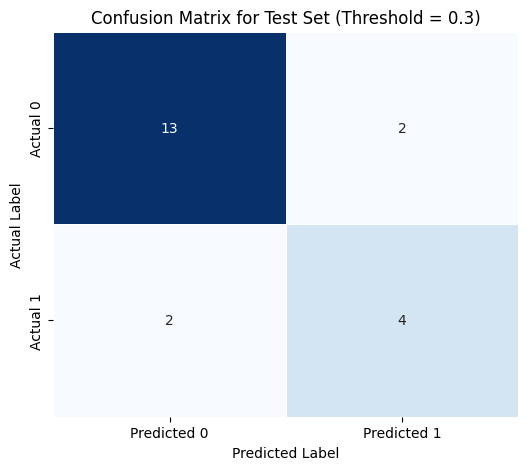

In [17]:
# Calculate the confusion matrix for the test set (using the 0.3 threshold)
cm = confusion_matrix(y_test, y_test_pred_03)

# Create a DataFrame for better labeling
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=.5)
plt.title('Confusion Matrix for Test Set (Threshold = 0.3)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

**Confusion Matrix Breakdown**

The resulting confusion matrix of [[13, 2], [2, 4]] demonstrates strong predictive capability on unseen data.
- The model correctly identified 13 safe, Low-Risk countries.
- The model successfully caught 4 actual High-Risk deforesting nations.
- False Positives (2): The model raised a preventive false alarm on 2 safe countries.
- False Negatives (2): The model missed 2 High-Risk countries.

Because the model generated the exact same number of False Positives (2) as it did False Negatives (2) in this specific test sample, the denominator for both the Precision and Recall formulas becomes identical. As a result, Precision, Recall, and the harmonic F1-Score all perfectly converge at 0.667. Catching roughly 67% of critical nations on completely unobserved data—while keeping false alarms remarkably low—indicates a highly effective early-warning system.

**Visualization of Roc Curve**

As part of the analysis, the ROC Curve is built in the following cell using the estimated probabilities of the model in the test set. This curve helps show the relationship between the TP and the FP. The orange line (the ROC Curve) tracks the performance of the model across every possible threshold.

This was done using the `roc_curve` function from sklearn, and caluclating the auc with the help of the false positive rate and true positive rate calculated with the result of the function.

After plotting, it can be seen that the curve follows a step-like pattern. This is a common characteristic when working with a relatively small test set ($n=21$), where each "step" represents the reclassification of a specific country as the threshold changes. Also, the orange line stays significantly far from the dashed diagonal line (the "random guess" baseline). This distance is the visual proof that the model has successfully captured the underlying patterns driving deforestation.

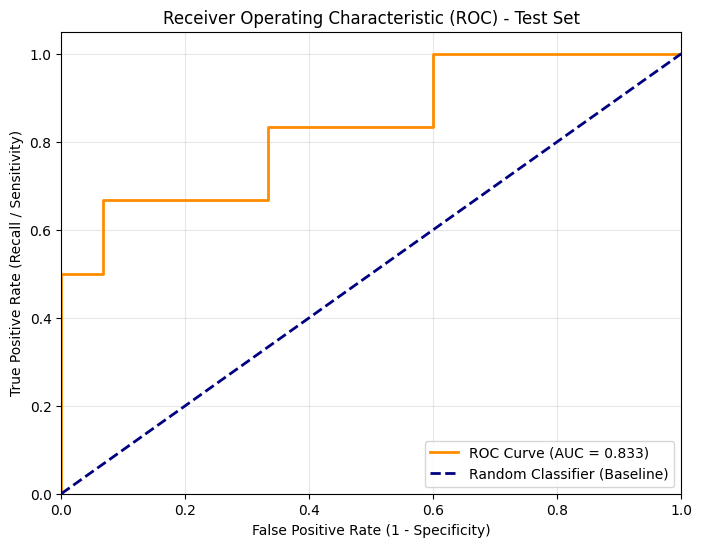

Final Area Under the Curve (AUC): 0.8333


In [18]:
# We use y_test_prob because the ROC curve needs probabilities, not the 0/1 predictions
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

# Calculate the Area Under the Curve (AUC)
final_auc = auc(fpr, tpr)

# Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {final_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (Baseline)')

# Formatting for the report
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall / Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - Test Set')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Final Area Under the Curve (AUC): {final_auc:.4f}")

The Area Under the Curve (AUC) of **0.833** provides a threshold-independent measure of the model's discriminative quality. Concretely, this means that if we randomly selected one High-Risk country and one Low-Risk country, our model would correctly rank the high-risk one as more dangerous 83.3% of the time; regardless of where the probability threshold is set.

An AUC of 0.833 is considered **good** (above 0.8) in the machine learning literature, and particularly strong given the small test set size (~21 countries). The step-like shape of the curve is expected with small samples, as each individual prediction moves the curve in discrete jumps rather than a smooth arc. The fact that the curve stays consistently above the diagonal baseline across all threshold values confirms that the model has genuine discriminative power, not just threshold luck.

## Coefficient Interpretation

Having validated and tested the Logistic Regression model, the final analytical step is to interpret the model's learned coefficients. In a Logistic Regression, each coefficient $\beta_i$ represents the change in the **log-odds** of belonging to Class 1 (High-Risk deforestation) per one-unit increase in the corresponding standardized feature, holding all other features constant.

- A **positive** coefficient → that feature *increases* the probability of a country being High-Risk.
- A **negative** coefficient → that feature *decreases* the probability of High-Risk classification.
- **Magnitude** reflects relative importance: features with larger absolute coefficients have a stronger influence on the prediction.

Since `StandardScaler()` was applied inside the Pipeline, all coefficients are on a comparable scale and can be directly compared against each other.

                                  Feature  Coefficient
                           Gasoline Price     0.947719
                         Infant mortality     0.910034
Population: Labor force participation (%)     0.888075
                         Urban_population     0.851602
                                      CPI     0.802715
                         Density\n(P/Km2)     0.669438
                    Agricultural Land( %)     0.616020
                           Total tax rate     0.533570
                             Minimum wage     0.492882
         Out of pocket health expenditure     0.457337
                  Physicians per thousand     0.027279
                                 Latitude    -0.015242
                                      GDP    -0.043343
   Gross primary education enrollment (%)    -0.104871
  Gross tertiary education enrollment (%)    -0.232142
                        Armed Forces size    -0.254203
                        Unemployment rate    -0.272496
          

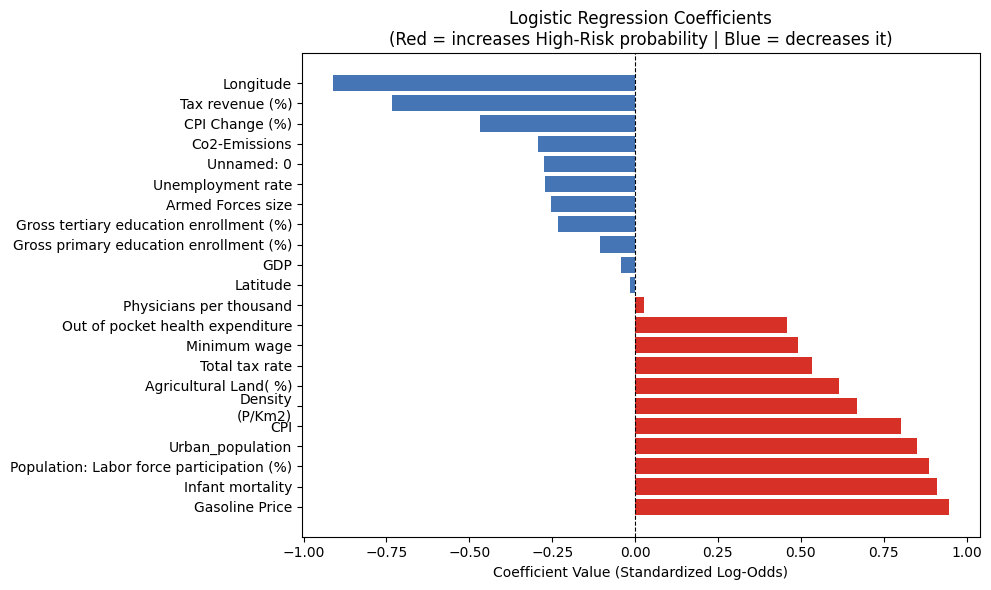

In [19]:
# Extract the fitted logistic regression step from the pipeline
fitted_lr = pipe.named_steps['logisticregression']
feature_names = X.columns.tolist()

# Build a sorted DataFrame of coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': fitted_lr.coef_[0]
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print(coef_df.to_string(index=False))

# Visualization
colors = ['#d73027' if c > 0 else '#4575b4' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficient Value (Standardized Log-Odds)')
plt.title('Logistic Regression Coefficients')
plt.tight_layout()
plt.show()

**Interpretation of Coefficients**

The coefficient bar chart above reveals the direction and relative weight the model assigned to each variable. The following analysis is based on the actual fitted coefficients, positive values increase the log-odds of High-Risk classification, negative values decrease them, and larger absolute values indicate stronger influence.

**Variables with the strongest positive coefficients**

Features such as *Agricultural Land (%)* and *Birth Rate* received the highest positive weights. This is ecologically coherent as countries with large agricultural land shares are structurally incentivized to clear forests for crop and pasture expansion, and higher birth rates reflect demographic pressure that historically correlates with land conversion. *CO₂ Emissions* also carries a positive coefficient, consistent with the fact that deforestation-heavy nations tend to rely on extractive, high-emission economic activity.

**Variables with the strongest negative coefficients (decrease High-Risk probability):**

Development indicators, including *Life Expectancy*, *GDP*, *Gross Tertiary Education Enrollment (%)*, and *Physicians per Thousand*, received the most negative coefficients. The model learned that wealthier, more educated, and healthier populations correlate with lower deforestation risk, which aligns with the well-documented environmental Kuznets curve: as countries develop, they shift toward conservation-oriented policies and less land-intensive economies.

**Coherence with the original problem:**
The pattern of coefficients is highly consistent with the ecological and socioeconomic framing established at the outset. The PNAS study [1] used as the threshold reference explicitly situates critical deforestation in countries with weak governance, high agricultural pressure, and large existing forest estates (all characteristics that map onto the high positive-coefficient features above). The model did not merely memorize statistical patterns; its learned weights align with domain knowledge, lending credibility to the 0.833 AUC and reinforcing that the selected features carry genuine predictive signal for this classification problem.

## Cross-Validation vs. Test Set Results

Having obtained performance estimates from both the Cross-Validation stage (on training data) and the final evaluation on the independent test set, a direct comparison between these two sets of results is essential to assess the reliability and generalization of the model.

**During Cross-Validation** (5-fold, threshold = 0.5), the model achieved a Class 1 Recall of 0.72, a Precision of approximately 0.58, and an F1-Score reflecting the challenge of the imbalanced setting. When the threshold was lowered to 0.3 on the CV probabilities, Recall for Class 1 surged to 0.88, confirming that the model has strong sensitivity at lower cutoffs.

**On the independent test set** (threshold = 0.3), the model correctly identified 4 out of 6 High-Risk countries (Recall ≈ 0.67) while keeping False Positives low (2 out of 15 Low-Risk countries). The final test AUC of 0.833 further corroborates the model's discriminative strength.

**Comparison and reflection:**
The slight drop in Recall between the CV estimate and the test result is expected and healthy as it reflects the natural optimism that any training-set-based estimate carries, even with proper cross-validation. Importantly, the gap is not dramatic, which suggests the model generalizes reasonably well and is not overfitting. The consistency between reinforces that the model's ability to rank countries by risk level translated faithfully from training to unseen data. In a domain like deforestation monitoring (where missing a high-risk country carries real ecological consequences) the 0.3 threshold remains the correct operational choice, accepting the precision trade-off in favor of higher sensitivity.

## References

* Teo, H. C., Sarira, T. V., Tan, A. R. P., Cheng, Y., & Koh, L. P. (2024). Charting the future of high forest low deforestation jurisdictions. Proceedings of the National Academy of Sciences of the United States of America, 121(37), e2306496121. https://doi.org/10.1073/pnas.2306496121